In [1]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [2]:
# check current versions in Colab
import sklearn
import numpy
print("sklearn:", sklearn.__version__)
print("numpy:", numpy.__version__)

sklearn: 1.4.2
numpy: 1.26.4


In [3]:
# Importing the data
housing = pd.read_csv("housing.csv")


## Looking at the Data Structure

In [4]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
housing['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [7]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


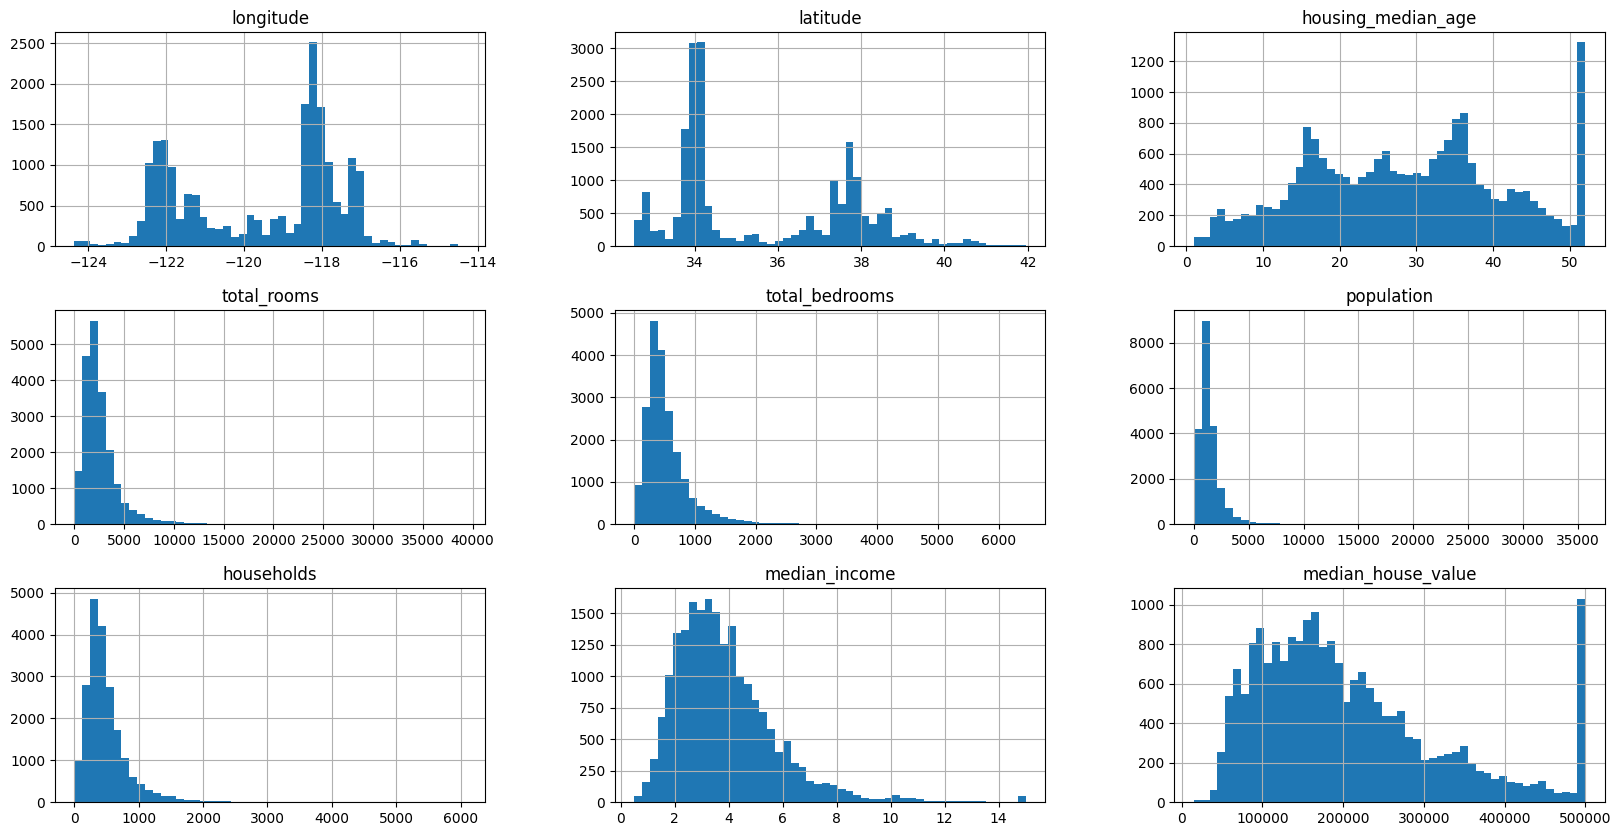

In [8]:
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20, 10))
plt.show()

1. Median income is scaled i.e. 3 = `$30,000` and 1.5 = `$1500` [We dont need to scale it]
2. Median House Value is capped at `$500,000` i.e. any house whose price is higher than 500,000 will be capped at that range.
3. Attributes are not scaled uniformily due to which certain algorithm may struggle here. Solution is `feature scaling (StandardScaler, MinMaxScaler)`.
4. Tail Heavy Distribution (Skewed Right)

## Splitting the data in training and test set

In [9]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

`Random split` is okay, but it can accidentally create train and test sets that don’t reflect the real data distribution. For example, if your dataset has 90% low-income and 10% high-income samples, a random split might end up putting most low-income samples into the test set and fewer into the train set. This makes the model learn an unbalanced view of the data and gives unreliable evaluation results. That’s why we use stratified sampling when data has important categories like income levels.

- Continuous numbers → Convert to categories for stratified splitting (can't stratify on continuous numbers directly.)
- Use `pd.cut()` to bin values
- Keep limited categories (5-10) so each has enough samples
- Create → Use for split → Drop after splitting (don't keep as feature)

In [10]:
import numpy as np

housing['income_cat'] = pd.cut(housing['median_income'],
                               bins = [0, 1.5, 3.0, 4.5, 6, np.inf],
                               labels = [1, 2, 3, 4, 5])

The `pd.cut()` function in pandas is used to bin continuous numerical data into discrete intervals

In [11]:
housing.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5


In [12]:
housing['income_cat'].value_counts().sort_values()

,count
income_cat,
1,822
5,2362
4,3639
2,6581
3,7236


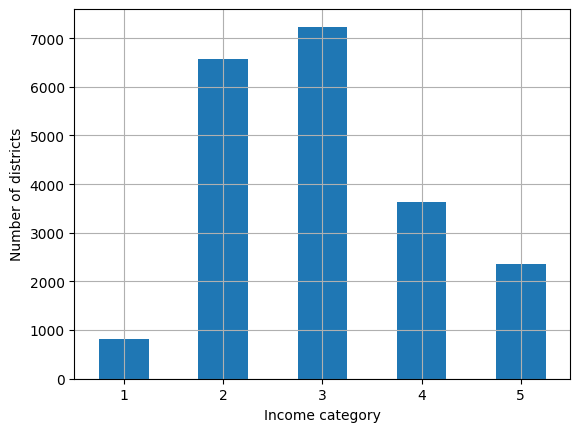

In [13]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [14]:
len(housing)

20640

In [15]:
# Doing stratifiedshufflesplit
strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2,
                                                   stratify=housing['income_cat'],  random_state=42)

In [16]:
len(strat_train_set), len(strat_test_set)

(16512, 4128)

In [17]:
strat_train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND,2
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN,5
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND,2
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN,2
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN,3


In [18]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set) * 100

,count
income_cat,
3,35.053295
2,31.879845
4,17.635659
5,11.434109
1,3.997093


In [19]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

We just need `income_cat` to split data in stratified. So after splitting we drop it

# Discover and Visualize the Data to Gain Insights


In [20]:
# housing = strat_train_set.copy()

## Visualizing Geographical Data

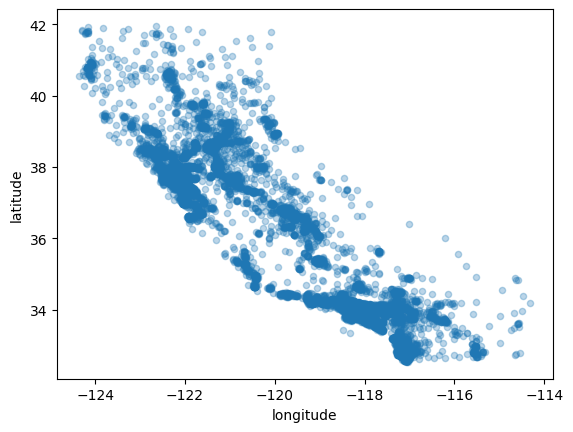

In [21]:
strat_train_set.plot(kind='scatter', x='longitude', y='latitude', alpha=0.3)
plt.show()

This scatter plot represents housing districts across California using geographic coordinates, where longitude is on the x-axis and latitude is on the y-axis. Each dot corresponds to one district in the dataset. The darker regions appear because many semi-transparent points overlap there, indicating areas with a high concentration of housing districts or population, such as Los Angeles and the San Francisco Bay Area. Lighter or sparse regions represent less populated rural or desert areas. From this plot, we can understand that housing data is heavily concentrated near major cities and coastal regions, suggesting that location plays an important role in California housing patterns and likely affects house prices.

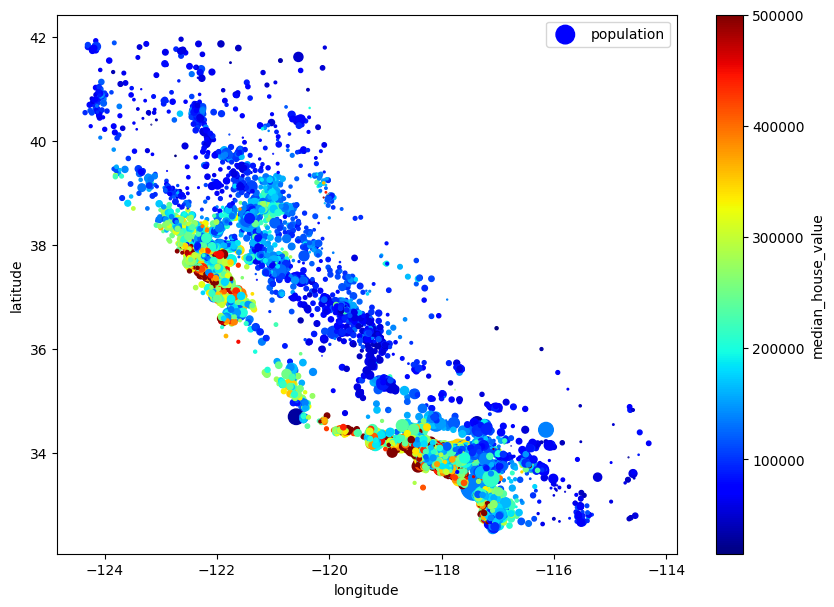

In [22]:
strat_train_set.plot(kind='scatter', x='longitude', y='latitude', s=strat_train_set['population']/100, label="population", figsize=(10,7), c="median_house_value",
             cmap=plt.get_cmap("jet"))
plt.show()

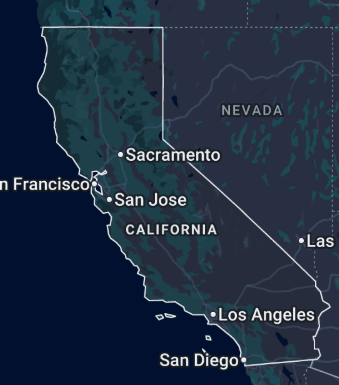

The scatter plot reveals that expensive houses (red dots) are concentrated along the coast, while cheaper houses (blue dots) are inland. Large dots indicate high-population areas like major cities. The graph clearly shows a strong relationship between location and house price — coastal properties cost more. However, the plot itself doesn't name specific regions (like San Francisco or LA); that requires outside knowledge of California's geography. For your model, keep latitude and longitude as features, as location is a powerful predictor of price.



## Looking for Correlations

In [23]:
strat_train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN


In [24]:
corr_matrix = strat_train_set.corr(numeric_only=True)

In [25]:
corr_matrix['median_house_value'].sort_values(ascending=False).round(3)

,median_house_value
median_house_value,1.000
median_income,0.687
total_rooms,0.135
housing_median_age,0.114
households,0.065
total_bedrooms,0.048
population,-0.027
longitude,-0.047
latitude,-0.143


This output shows the correlation between median_house_value and all other features in the dataset. Correlation measures how strongly two variables are related, with values ranging from -1 to 1.

- A value close to 1 means a strong positive realtionship (when one increases the other also increses)
- A value close to -1 means a strong negative relationship (when one increases the other decreses).
- A value near 0 means little or no linear realtionship

- From our result, `median_income` has the strongest positive correlation (0.688) with median_house_value, meaning areas with higher meidan income genreally have higher house prices
- Features like `total_room, housing_median_age and households` have negaitve correlation

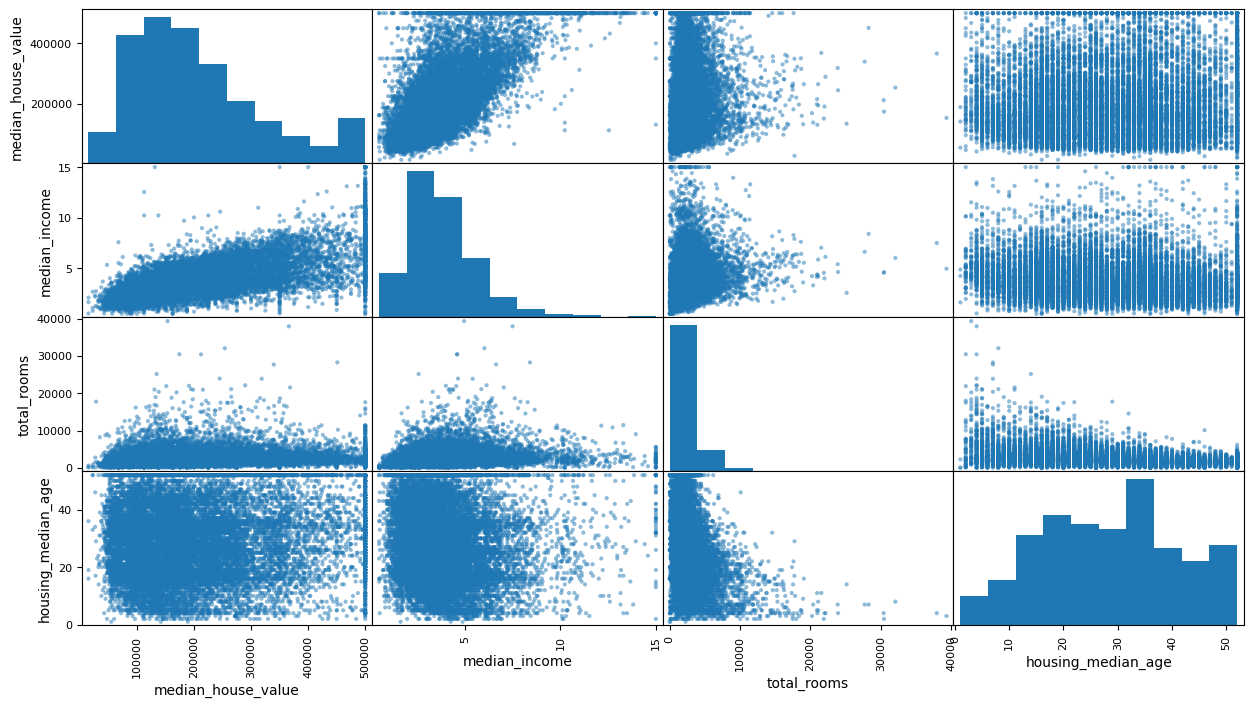

In [26]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(strat_train_set[attributes], figsize=(15, 8))
plt.show()

- `median_income` and `median_house_value` show a strong positive relationship. As income increases, house value generally increases. This is the clearest and most useful predictor visible in the dataset.
- The diagonal histograms show the distribution of each feature. median_income is right-skewed (most districts have lower-to-medium income), and `median_house_value` appears capped near the upper limit, which suggests the dataset has a maximum value cutoff.
- `total_rooms` contains extreme outliers. Some districts have unusually high room counts compared to most data points, which may require scaling or feature engineering.
- `housing_median_age` appears discrete rather than continuous because values form vertical stripes. This suggests age was recorded as integers or grouped values.
- Many relationships besides income are weak or noisy, meaning features like `total_rooms` alone are not strong predictors of house price.

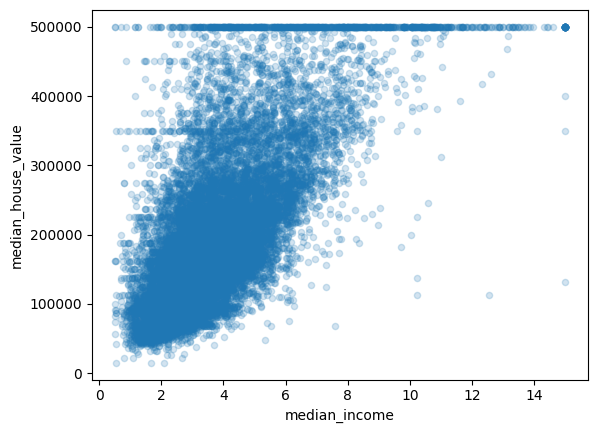

In [27]:
strat_train_set.plot(kind='scatter', x='median_income', y='median_house_value', alpha=0.2)
plt.show()

### Conclusion: Scatter Plot of Median Income vs Median House Value

The plot shows a strong positive correlation — higher income districts tend to have higher house prices. However, several horizontal lines are visible at $500k, $450k, $350k, and $280k. These are data quirks (artificial caps or rounding issues), not real patterns. If left in the data, the model will learn these fake patterns and make poor predictions. The recommendation is to remove districts that fall on these horizontal lines before training.

In [28]:
strat_train_set[strat_train_set['median_house_value'].isin([500000, 450000, 350000, 280000])]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
11493,-117.99,33.69,12.0,2480.0,858.0,1441.0,788.0,1.6705,350000.0,<1H OCEAN
1566,-121.96,37.74,2.0,200.0,20.0,25.0,9.0,15.0001,350000.0,<1H OCEAN
8895,-118.49,34.03,31.0,3155.0,808.0,1208.0,745.0,3.6769,450000.0,<1H OCEAN
19542,-120.92,37.63,39.0,45.0,8.0,22.0,9.0,1.7679,450000.0,INLAND
10258,-117.87,33.85,33.0,45.0,11.0,34.0,10.0,5.2949,350000.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
5642,-118.31,33.74,36.0,2464.0,472.0,1111.0,457.0,4.5074,350000.0,NEAR OCEAN
11463,-117.99,33.67,12.0,2228.0,479.0,1122.0,488.0,4.0385,350000.0,<1H OCEAN
5308,-118.44,34.05,32.0,1880.0,435.0,798.0,417.0,4.7109,500000.0,<1H OCEAN
1016,-121.76,37.67,6.0,3023.0,518.0,1225.0,468.0,6.3705,350000.0,INLAND


In [29]:
# Removing rows with suspiciious house values
housing_train = strat_train_set[~strat_train_set['median_house_value'].isin([500000, 450000, 350000, 280000])].copy()

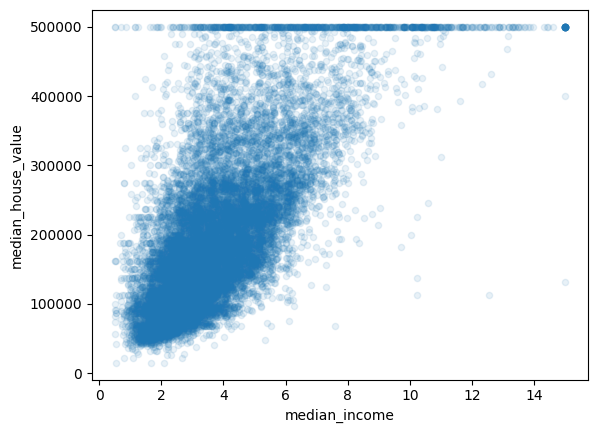

In [30]:
housing_train.plot(kind='scatter', x='median_income', y='median_house_value', alpha=0.1)
plt.show()

In [31]:
housing_train["rooms_per_house"] = housing_train["total_rooms"] / housing_train["households"]
housing_train["bedrooms_ratio"] = housing_train["total_bedrooms"] / housing_train["total_rooms"]
housing_train["people_per_house"] = housing_train["population"] / housing_train["households"]

In [32]:
corr_matrix = housing_train.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.699533
rooms_per_house,0.151893
total_rooms,0.141578
housing_median_age,0.110772
households,0.067638
total_bedrooms,0.050416
population,-0.023246
people_per_house,-0.026447
longitude,-0.044510


Interesting as the bedroom ration increses the price of house decreses

In [33]:
# Splitting the features and labels
X_train = housing_train.drop("median_house_value", axis=1)
y_train = housing_train["median_house_value"]

In [34]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_house,bedrooms_ratio,people_per_house
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND,5.485836,0.205784,3.168555
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN,6.927083,0.160714,2.623698
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND,5.393333,0.191595,2.223333
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN,3.886128,0.276505,1.859213
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN,6.096552,0.182692,3.167241
...,...,...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,<1H OCEAN,6.658342,0.184696,2.023976
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,INLAND,5.571932,0.179977,3.363188
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,<1H OCEAN,4.110465,0.234795,2.662791
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,<1H OCEAN,6.297405,0.183835,2.411178


## Data Cleaning

In [35]:
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer()
# housing_numerical = X_train.drop("ocean_proximity", axis=1)
# housing_numerical_imputed = imputer.fit_transform(housing_numerical)

In [36]:
# housing_numerical_imputed = pd.DataFrame(
#     housing_numerical_imputed,
#     columns=housing_numerical.columns
# )

## Handling Text and Categorical Attributes

In [37]:
# # Working with categorical attribute
# housing_category = X_train[['ocean_proximity']]
# housing_category.head()

In [38]:
# from sklearn.preprocessing import OneHotEncoder
# categorical_encoder = OneHotEncoder()
# housing_category_OneHot = categorical_encoder.fit_transform(housing_category)

There are different ways to convert categorical data into numbers.
- Ordinal encoding
- One-hot encoding

We use one-hot encoding here because the categories (like <1H OCEAN, INLAND, NEAR BAY) don’t have any natural order.

If we use ordinal encoding, it gives them ranks (0, 1, 2, 3…), which wrongly makes the model think one category is “greater” or “closer” than another.

So instead, one-hot encoding creates separate columns for each category and uses 0/1 values, so each category is treated equally without any fake ordering.

## ColumnTransformer pipeline for preprocessing

In [39]:
housing_train.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_house,bedrooms_ratio,people_per_house
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND,5.485836,0.205784,3.168555
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN,6.927083,0.160714,2.623698


In [40]:
X_train.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_house,bedrooms_ratio,people_per_house
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND,5.485836,0.205784,3.168555
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN,6.927083,0.160714,2.623698


In [41]:
y_train.head(2)

,median_house_value
12655,72100.0
15502,279600.0


In [42]:
# Apply different transformations to different column types (numerical vs categorical)

num_attribs = X_train.select_dtypes(include=[np.number]).columns
cat_attribs = ["ocean_proximity"]

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ('cat', OneHotEncoder(), cat_attribs)
])

In [43]:
housing_prepared = preprocessing.fit_transform(X_train)

In [44]:
housing_prepared

array([[-0.94381628,  1.34640285,  0.03074535, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.16996579, -1.1911794 , -1.72205048, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26548694, -0.12567525,  1.22583341, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.57345349,  1.30901674,  1.54452356, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56345925,  1.24826431, -1.16434272, ...,  0.        ,
         0.        ,  0.        ],
       [-1.28362049,  2.0240261 , -0.12859973, ...,  0.        ,
         0.        ,  0.        ]])

## Linear Regression

In [45]:
# Linear Regression (baseline model)
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, y_train)

LinearRegression()

In [46]:
# Checking performance -- training set first
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = lin_reg.predict(housing_prepared)

mse = mean_squared_error(y_train, y_pred)
LR_rmse = np.sqrt(mse).round(3)

print(LR_rmse)

66554.005


## Random Forest

In [47]:

# Random Forest
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(housing_prepared, y_train)

RandomForestRegressor(random_state=42)

In [48]:
y_pred_forest = forest_reg.predict(housing_prepared)
y_pred_forest[:5]

array([ 74200.  , 297546.01,  83269.  , 121204.  , 235013.  ])

In [49]:
list(y_train[:5])

[72100.0, 279600.0, 82700.0, 112500.0, 238300.0]

In [50]:
# Evaluating Performance Random Forest
mse = mean_squared_error(y_train, y_pred_forest)
RF_rmse = np.sqrt(mse).round(3)

print(RF_rmse)

18233.196


## Decision Tree

In [51]:
# Decision tree
from sklearn.tree import DecisionTreeRegressor

dec_tree = DecisionTreeRegressor()
dec_tree.fit(housing_prepared, y_train)

DecisionTreeRegressor()

In [52]:
y_pred_dec_tree = dec_tree.predict(housing_prepared)
y_pred_dec_tree[:5]

array([ 72100., 279600.,  82700., 112500., 238300.])

In [53]:
list(y_train[:5])

[72100.0, 279600.0, 82700.0, 112500.0, 238300.0]

In [54]:
# Evaluating Performance of Decision Tree
from sklearn.metrics import  mean_squared_error
DT_rmse = np.sqrt(mean_squared_error(y_pred_dec_tree, y_train))
print(DT_rmse)

0.0


## Testing

-- Feature Engineering always goes before fit_transform

In [55]:
# Now for testing we follow the same pipeline
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"]

##  Important:
For testing we only use transform on test but not fit_transform
Why?
Because the test set must be treated as completely unseen data and `fit_transform()` would learn from it which breaks the idea of evaluation.

-------

1. What `fit_transform()` does
- `fit` : Learn parameters from data (mean, std, vairance, etc. )
- `transform` : Applies those learned parameters to transform the data

Example:
- `StandardScaler.fit()` learns mean and std
- `OneHotEncoder.fit()` learns categories
- `TF-IDF.fit()` - leans vocabulary + weights

-------

2. Why do we use `fit_transform()` on training data
- Because we are allowed to learn patterns from training data.

-------

3. Why we only use `transform()` on test data.
- We don’t use fit() on the test set because the test data must remain completely unseen during training. If we fit on it, the model would learn statistics (mean, std, categories, etc.) from test data, causing data leakage. This would make evaluation unfair and overly optimistic. Instead, we reuse the parameters learned from the training set. So we only apply transform() to the test data.
-------

In [56]:
# X_test = strat_test_set.drop("median_house_value", axis=1)
# y_test = strat_test_set["median_house_value"]

# X_test_prepared = preprocessing.transform(X_test)

The above code throws error because one of the key role in ML is whatever transformation or feature engineering
we apply on the training data Must also applied to the test data.

In [57]:
# for dataset in (X_train, X_test):
#     dataset["rooms_per_house"] = dataset["total_rooms"] / dataset["households"]
#     dataset["people_per_house"] = dataset["population"] / dataset["households"]
#     dataset["bedrooms_ratio"] = dataset["total_bedrooms"] / dataset["total_rooms"]

In [58]:
X_test["rooms_per_house"]  = X_test["total_rooms"]  / X_test["households"]
X_test["people_per_house"] = X_test["population"]   / X_test["households"]
X_test["bedrooms_ratio"]   = X_test["total_bedrooms"] / X_test["total_rooms"]

In [59]:
X_test_prepared = preprocessing.transform(X_test)

## Linear Regression (Test Set)

In [60]:
# Predict on test set

y_test_pred = lin_reg.predict(X_test_prepared)
y_test_pred[:5].round(3)

array([429236.248, 284808.165, 238767.619, 187532.497, 258730.138])

In [61]:
list(y_test[:5])

[500001.0, 162500.0, 204600.0, 159700.0, 184000.0]

In [62]:
# Evaluate on test set Linear Regression

from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, y_test_pred)
LR_rmse_test = np.sqrt(mse)

print(LR_rmse_test)

66769.95384494902


## Random Forest (Test Set)

In [63]:
# Predict on test set
forest_pred = forest_reg.predict(X_test_prepared)

# Evaluate
mse = mean_squared_error(y_test, forest_pred)
RF_rmse_test = np.sqrt(mse).round(3)

print("Random Forest RMSE:", RF_rmse_test)

Random Forest RMSE: 48235.798


## Decision Tree (Test Set)

In [64]:
dec_predict = dec_tree.predict(X_test_prepared)

# Evulation
DT_rmse_test = np.sqrt(mean_squared_error(y_test, dec_predict)).round(3)

print(DT_rmse_test)

70263.883


## Comparing the training and testing of each model

In [65]:
data = {
    'model': ['Linear Regression', 'Random Forest', 'Decision Tree'],
    'Training_mse': [LR_rmse, RF_rmse, DT_rmse],
    'Testing_mse': [LR_rmse_test, RF_rmse_test, DT_rmse_test]
}

df = pd.DataFrame(data)
df.round(3)

,model,Training_mse,Testing_mse
0,Linear Regression,66554.005,66769.954
1,Random Forest,18233.196,48235.798
2,Decision Tree,0.000,70263.883


- The `Decision Tree` model is severely overfitted. Its training RMSE is 0, meaning it memorized the training data perfectly, but its testing RMSE increased drastically to 69655. This shows that the model failed to generalize to unseen data and only performed well on the training set.
- The `Linear Regression model` is underfitted because both the training RMSE (66554) and testing RMSE (66769) are high and very similar. This indicates that the model is too simple to capture the complex relationships in the dataset, so it performs poorly on both training and testing data.
- To reduce overfitting, we can reduce model complexity, tune hyperparameters, use cross-validation, add more training data, or limit the depth of tree-based models. To solve underfitting, we can use more powerful models, improve feature engineering, or add more meaningful features.
- Since the Random Forest model currently performs the best, the next step would be hyperparameter tuning using methods like GridSearchCV, improving feature engineering, and possibly trying stronger ensemble models such as XGBoost, LightGBM, or CatBoost.

<Axes: title={'center': 'Comparision of the model'}, xlabel='model'>

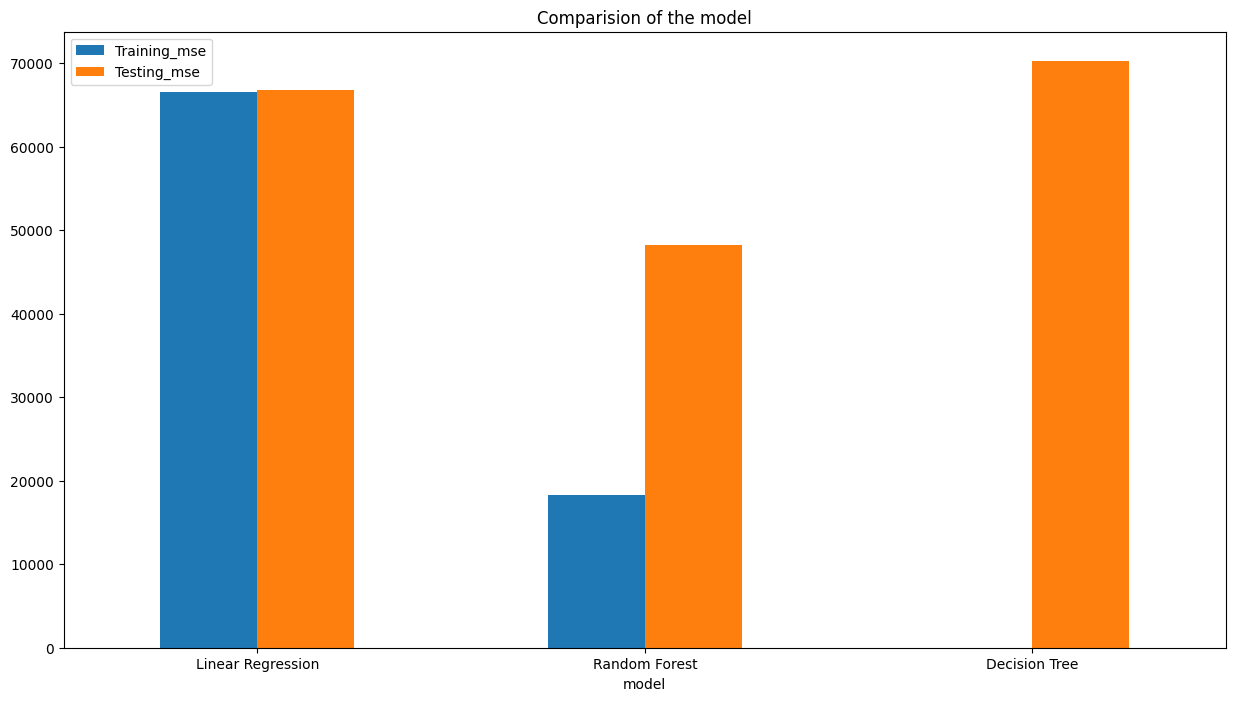

In [66]:
df.plot(x='model', kind='bar', title='Comparision of the model', figsize=(15, 8), rot=0)

## **Cross Validation**

## Linear Regression CV

In [67]:
housing_prepared

array([[-0.94381628,  1.34640285,  0.03074535, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.16996579, -1.1911794 , -1.72205048, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26548694, -0.12567525,  1.22583341, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.57345349,  1.30901674,  1.54452356, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56345925,  1.24826431, -1.16434272, ...,  0.        ,
         0.        ,  0.        ],
       [-1.28362049,  2.0240261 , -0.12859973, ...,  0.        ,
         0.        ,  0.        ]])

In [68]:
from sklearn.model_selection import cross_val_score

LR_scores = cross_val_score(lin_reg, housing_prepared, y_train, scoring='neg_mean_squared_error', cv=10)
LR_rmse = np.sqrt(-LR_scores)
print("Linear Regression RMSE:", LR_rmse.mean().round(3))
print("Std:", LR_rmse.std().round(3))

Linear Regression RMSE: 66770.41
Std: 2428.28


## Random Forest CV

In [69]:
from sklearn.model_selection import cross_val_score

RF_scores = cross_val_score(forest_reg, housing_prepared, y_train, scoring='neg_mean_squared_error', cv=10)
RF_rmse = np.sqrt(-RF_scores)
print("Random Forest RMSE:", RF_rmse.mean().round(3))
print("Std:", RF_rmse.std().round(3))

Random Forest RMSE: 48992.12
Std: 2141.333


## Decision Tree

In [70]:
from sklearn.model_selection import cross_val_score

DT_scores = cross_val_score(dec_tree, housing_prepared, y_train, scoring='neg_mean_squared_error', cv=10)
DT_rmse = np.sqrt(-DT_scores)
print("Decision Tree RMSE:", DT_rmse.mean().round(3))
print("Std:", DT_rmse.std().round(3))

Decision Tree RMSE: 68377.652
Std: 3118.464


## Cross Validation Comparison Table

In [71]:
import pandas as pd

results = pd.DataFrame(
    {
        "Model": ["Linear Regression", "Random Forest", "Decision Tree"],
        "Mean_RMSE": [
            LR_rmse.mean(),
            RF_rmse.mean(),
            DT_rmse.mean()
        ],
         "Std_RMSE": [
             LR_rmse.std(),
             RF_rmse.std(),
             DT_rmse.std()
    ]
    }
)

results = results.round(3)
results

,Model,Mean_RMSE,Std_RMSE
0,Linear Regression,66770.410,2428.280
1,Random Forest,48992.120,2141.333
2,Decision Tree,68377.652,3118.464


## Hyperparameter Tuning (GridSearchCV)

In [72]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [3, 10, 30],
     'max_features': [2, 4, 6, 8]},
]

grid_search = GridSearchCV(forest_reg,
                           param_grid,
                           cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)

grid_search.fit(housing_prepared, y_train)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [73]:
# Best model from GridSearch

print("Best params:", grid_search.best_params_)

Best params: {'max_features': 6, 'n_estimators': 30}


In [74]:
# Best estimator

best_model = grid_search.best_estimator_
best_model

RandomForestRegressor(max_features=6, n_estimators=30, random_state=42)

In [75]:
# Evaluate best model on test set

from sklearn.metrics import mean_squared_error
import numpy as np

final_pred = best_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_pred)
final_rmse = np.sqrt(final_mse)

print("Final RMSE:", final_rmse)

Final RMSE: 47712.921126662164


In [76]:
(housing['median_house_value']).mean()

206855.81690891474

## Model Performance:
- RMSE = 47,000 on an average house price of about 206,856
- Relative error ≈ 22.7%, meaning the model’s predictions deviate from actual prices by about 23% on average.
- This indicates moderate predictive performance, though there is still room for improvement.

## Saving Trained Model

In [77]:
# Using joblib
import joblib

joblib.dump(best_model, "housing_model.pkl")

['housing_model.pkl']

In [78]:
# # Later we can load and predict with saved model as follows

# import joblib
# loaded_model = joblib.load('housing_model.pkl')

# # Using it to make predictions as
# predictions = loaded_model.predict(X_test_prepared)
# print(predictions[:5])

In [79]:
import joblib
joblib.dump(preprocessing, "preprocessing.pkl")
joblib.dump(best_model, "model.pkl")

['model.pkl']